# To show the final comparison between ARMA and Linear regression (Standard and Ridge)

In [71]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import os 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from itertools import product

In [72]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import TimeSeriesSplit

In [73]:
import sys
sys.path.append("..")
from scripts.window_regressor import Window_Regressor_Sequence_to_scalar

ARMA MODEL 

In [74]:
class ARIMA_model():
    def __init__(self, time_series: pd.Series, horizon: int, order:tuple, split_location: int, train_start=0):
        self.data = time_series
        self.horizon = horizon
        self.order = order 
        self.split_location = split_location
        self.train_start = train_start
        self.T = len(self.data)
        self.y_true = self.data[self.split_location:]

    def predict(self):
        y_pred = []
        j = self.split_location
        current_start = self.train_start
        while j < self.T:
            steps_to_forecast = min(self.horizon, self.T - j)
            data_to_train = self.data[current_start:j]
            try:
                model = SARIMAX(
                    endog=data_to_train,
                    order=(self.order[0], 1, self.order[1]),
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit(disp=False, maxiter=50)
                predictions = model.forecast(steps=steps_to_forecast)
            except (np.linalg.LinAlgError, ValueError, np.linalg.LinAlgError, Exception) as e:
                last_val = data_to_train.iloc[-1] # Naive
                predictions = np.full(steps_to_forecast, last_val)
            y_pred.extend(predictions)
            j += steps_to_forecast
            current_start += steps_to_forecast
        self.y_pred = np.array(y_pred[:len(self.y_true)])
        return self.y_pred

    def measure_performance(self, minutes_list):
        metrics = [mean_squared_error, mean_absolute_error, mean_absolute_percentage_error]
        metric_names = ['MSE', 'MAE', 'MAPE']
        array_results = np.zeros(shape=(len(metric_names), len(minutes_list)))

        results = {m: ([], []) for m in minutes_list}  # (y_true, y_pred)

        j = self.split_location
        while j < self.T:
            horizon_available = min(self.horizon, self.T - j)
            for m in minutes_list:
                if m <= horizon_available:
                    idx = j - self.split_location + m - 1
                    if idx < len(self.y_true):
                        y_true_m = self.y_true.iloc[idx]
                        y_pred_m = self.y_pred[idx]
                        results[m][0].append(y_true_m)
                        results[m][1].append(y_pred_m)
            j += horizon_available

        for i, metric in enumerate(metrics):
            for j, m in enumerate(minutes_list):
                y_t, y_p = results[m]
                if len(y_t) > 0:
                    array_results[i, j] = metric(y_t, y_p)
                else:
                    array_results[i, j] = np.nan

        return pd.DataFrame(data=array_results, index=metric_names, columns=minutes_list)


In [75]:
class ARIMA_model_optimized():
    def __init__(self, time_series: pd.Series, horizon: int, split_location: int, train_start=0):
        self.data = time_series
        self.horizon = horizon
        self.split_location = split_location
        self.train_start = train_start
        self.T = len(self.data)
        self.combinations = self.get_combinations()
        self.y_true = self.data[self.split_location:]


    def get_combinations(self):
        range_start = 0
        range_end = 5
        combinations = list(product(range(range_start, range_end), repeat=2))
        return combinations

    def optimize_ARIMA(self, endog: pd. Series) -> tuple:
        results = {order: None for order in self.combinations}

        for order in self.combinations:
            try:
                model = SARIMAX(endog, order=(order [0], 1, order[1]), simple_differencing=False).fit(disp=False)
                aic = model.aic
                if aic is not None:
                    results[order] = aic 
            except:
                continue
        valid_results = {k: v for k, v in results.items() if v is not None}
        sorted_orders = sorted(valid_results.items(), key=lambda x : x[1])
        best_order, _ = sorted_orders[0]
        return best_order

    def predict(self):
        y_pred = []
        j = self.split_location
        current_start = self.train_start
        while j < self.T:
            steps_to_forecast = min(self.horizon, self.T - j)
            data_to_train = self.data[current_start:j]
            order = self.optimize_ARIMA(endog=data_to_train)
            last_val = data_to_train.iloc[-1] 
            try:
                model = SARIMAX(
                    endog=data_to_train,
                    order=(order[0], 1, order[1]),
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit(disp=False, maxiter=50)
                predictions = model.forecast(steps=steps_to_forecast)

            except (np.linalg.LinAlgError, ValueError, np.linalg.LinAlgError, Exception) as e:
                predictions = np.full(steps_to_forecast, last_val)

            predictions = np.where(np.isnan(predictions), last_val, predictions) ## To avoid Nan neverthless if the model has compiled

            y_pred.extend(predictions)
            j += steps_to_forecast
            current_start += steps_to_forecast
        self.y_pred = np.array(y_pred[:len(self.y_true)])
        return self.y_pred

    def measure_performance(self, minutes_list):
        metrics = [mean_squared_error, mean_absolute_error, mean_absolute_percentage_error]
        metric_names = ['MSE', 'MAE', 'MAPE']
        array_results = np.zeros(shape=(len(metric_names), len(minutes_list)))

        results = {m: ([], []) for m in minutes_list}  # (y_true, y_pred)

        j = self.split_location
        while j < self.T:
            horizon_available = min(self.horizon, self.T - j)
            for m in minutes_list:
                if m <= horizon_available:
                    idx = j - self.split_location + m - 1
                    if idx < len(self.y_true):
                        y_true_m = self.y_true.iloc[idx]
                        y_pred_m = self.y_pred[idx]
                        results[m][0].append(y_true_m)
                        results[m][1].append(y_pred_m)
            j += horizon_available

        for i, metric in enumerate(metrics):
            for j, m in enumerate(minutes_list):
                y_t, y_p = results[m]
                if len(y_t) > 0:
                    array_results[i, j] = metric(y_t, y_p)
                else:
                    array_results[i, j] = np.nan

        return pd.DataFrame(data=array_results, index=metric_names, columns=minutes_list)


LINEAR MODEL 

In [76]:
class Linear_model():
    def __init__(self, time_series: pd.Series, window_size: int, split_location: int, max_horizon: int):
        self.data = time_series
        self.window_size = window_size
        self.split_location = split_location
        self.max_horizon = max_horizon
        self.T = len(self.data)
        self.y_true = self.data[self.split_location:]

    def fit(self):
        train = self.data[:self.split_location]
        models = []
        for horizon_i in range(1, self.max_horizon+1):
            proper_ml_data = Window_Regressor_Sequence_to_scalar(time_series_data=train, window_size=self.window_size, horizon=horizon_i).generate_data_set().values
            X = proper_ml_data[:, :-1]
            y = proper_ml_data[:, -1]
            model_i = Pipeline(steps=[('scaler', MinMaxScaler(feature_range=(0,1))), ('model', LinearRegression())])
            model_i.fit(X, y)
            models.append(model_i)
        self.models = models



    def predict(self):
        y_pred = []
        j = self.split_location
        while j < self.T:
            steps_to_forecast = min(self.max_horizon, self.T - j)
            window = self.data.values[:j][-self.window_size:].reshape(1, -1) ## Input
            predictions = []

            for horizon_i in range(steps_to_forecast):
                model_h_i = self.models[horizon_i]
                prediction_h_i = model_h_i.predict(window)
                predictions.append(prediction_h_i)

            y_pred.extend(predictions)
            j += steps_to_forecast
        self.y_pred = np.array(y_pred[:len(self.y_true)])
        return self.y_pred
    

    def measure_performance(self, minutes_list):
        metrics = [mean_squared_error, mean_absolute_error, mean_absolute_percentage_error]
        metric_names = ['MSE', 'MAE', 'MAPE']
        array_results = np.zeros(shape=(len(metric_names), len(minutes_list)))

        results = {m: ([], []) for m in minutes_list}  # (y_true, y_pred)

        j = self.split_location
        while j < self.T:
            horizon_available = min(self.max_horizon, self.T - j)
            for m in minutes_list:
                if m <= horizon_available:
                    idx = j - self.split_location + m - 1
                    if idx < len(self.y_true):
                        y_true_m = self.y_true.iloc[idx]
                        y_pred_m = self.y_pred[idx]
                        results[m][0].append(y_true_m)
                        results[m][1].append(y_pred_m)
            j += horizon_available

        for i, metric in enumerate(metrics):
            for j, m in enumerate(minutes_list):
                y_t, y_p = results[m]
                if len(y_t) > 0:
                    array_results[i, j] = metric(y_t, y_p)
                else:
                    array_results[i, j] = np.nan

        return pd.DataFrame(data=array_results, index=metric_names, columns=minutes_list)


In [77]:
class Ridge():
    def __init__(self, time_series: pd.Series, window_size: int, split_location: int, max_horizon: int):
        self.data = time_series
        self.window_size = window_size
        self.split_location = split_location
        self.max_horizon = max_horizon
        self.T = len(self.data)
        self.y_true = self.data[self.split_location:]

    def fit(self):
        train = self.data[:self.split_location]
        models = []
        for horizon_i in range(1, self.max_horizon+1):
            proper_ml_data = Window_Regressor_Sequence_to_scalar(time_series_data=train, window_size=self.window_size, horizon=horizon_i).generate_data_set().values
            X = proper_ml_data[:, :-1]
            y = proper_ml_data[:, -1]
            model_i = Pipeline(steps=[
                ('scaler', MinMaxScaler(feature_range=(0, 1))),
                ('model', RidgeCV(
                    alphas=np.logspace(-4, 4, 50),   # ajustable
                    cv=None,                         # ← GCV
                    store_cv_results=False
                ))
            ])
            model_i.fit(X, y)
            models.append(model_i)
        self.models = models


    def predict(self):
        y_pred = []
        j = self.split_location
        while j < self.T:
            steps_to_forecast = min(self.max_horizon, self.T - j)
            window = self.data.values[:j][-self.window_size:].reshape(1, -1) ## Input
            predictions = []

            for horizon_i in range(steps_to_forecast):
                model_h_i = self.models[horizon_i]
                prediction_h_i = model_h_i.predict(window)
                predictions.append(prediction_h_i)

    
            y_pred.extend(predictions)
            j += steps_to_forecast
        self.y_pred = np.array(y_pred[:len(self.y_true)])
        return self.y_pred
    

    def measure_performance(self, minutes_list):
        metrics = [mean_squared_error, mean_absolute_error, mean_absolute_percentage_error]
        metric_names = ['MSE', 'MAE', 'MAPE']
        array_results = np.zeros(shape=(len(metric_names), len(minutes_list)))

        results = {m: ([], []) for m in minutes_list}  # (y_true, y_pred)

        j = self.split_location
        while j < self.T:
            horizon_available = min(self.max_horizon, self.T - j)
            for m in minutes_list:
                if m <= horizon_available:
                    idx = j - self.split_location + m - 1
                    if idx < len(self.y_true):
                        y_true_m = self.y_true.iloc[idx]
                        y_pred_m = self.y_pred[idx]
                        results[m][0].append(y_true_m)
                        results[m][1].append(y_pred_m)
            j += horizon_available

        for i, metric in enumerate(metrics):
            for j, m in enumerate(minutes_list):
                y_t, y_p = results[m]
                if len(y_t) > 0:
                    array_results[i, j] = metric(y_t, y_p)
                else:
                    array_results[i, j] = np.nan

        return pd.DataFrame(data=array_results, index=metric_names, columns=minutes_list)


Just to add an MLP 

In [78]:
from sklearn.base import BaseEstimator, RegressorMixin
import torch.nn as nn
import torch 
from torch.utils.data import TensorDataset, DataLoader

In [79]:
class MLP_one_layer(BaseEstimator, RegressorMixin):
    def __init__(self, epochs, lr, batch_size, hidden_size, in_features):
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size
        self.hidden_size = hidden_size
        self.in_features = in_features

    def _build_model(self):
        class Fully_Connected(nn.Module):
            def __init__(self, in_features, hidden_size):
                super().__init__()
                self.linear_1 = nn.Linear(in_features=in_features, out_features=hidden_size)
                self.linear_2 = nn.Linear(in_features=hidden_size, out_features=1)
          
            def forward(self, x):
                x = torch.relu(self.linear_1(x))
                x = self.linear_2(x)
                return x.squeeze(-1)
            
        return Fully_Connected(in_features=self.in_features, hidden_size=self.hidden_size)

    def fit(self, X_train, y_train):
        X = np.array(X_train)
        y = np.array(y_train).flatten()

        
        self.scaler_x_ = MinMaxScaler(feature_range=(0,1))
        self.scaler_y_ = MinMaxScaler(feature_range=(0,1))
        X_scaled = self.scaler_x_.fit_transform(X)
        y_scaled = self.scaler_y_.fit_transform(y.reshape(-1, 1)).flatten()

    
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
        y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

        
        dataset = TensorDataset(X_tensor, y_tensor)
        train_loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)

        
        self.model_ = self._build_model()
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        criterion = nn.MSELoss()

    
        self.model_.train()
        for _ in range(self.epochs):
            for xb, yb in train_loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(xb), yb)
                loss.backward()
                optimizer.step()
        return self

    def predict(self, X):
        X = np.array(X)
        X_scaled = self.scaler_x_.transform(X)  
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

        self.model_.eval()
        with torch.no_grad():
            y_pred_scaled = self.model_(X_tensor).numpy()
        y_pred = self.scaler_y_.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        return y_pred

MLP MODEL

In [80]:
class MLP_model():
    def __init__(self, time_series: pd.Series, window_size: int, split_location: int, max_horizon: int, epochs=300, lr=0.01, batch_size=128 , hidden_size=24):
        self.data = time_series
        self.window_size = window_size
        self.split_location = split_location
        self.max_horizon = max_horizon
        self.T = len(self.data)
        self.y_true = self.data[self.split_location:]

        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size
        self.hidden_size = hidden_size
        self.in_features = self.window_size

    def fit(self):
        train = self.data[:self.split_location]
        models = []
        for horizon_i in range(1, self.max_horizon+1):
            proper_ml_data = Window_Regressor_Sequence_to_scalar(time_series_data=train, window_size=self.window_size, horizon=horizon_i).generate_data_set().values
            X = proper_ml_data[:, :-1]
            y = proper_ml_data[:, -1]
            model_i = MLP_one_layer(epochs=self.epochs, lr=self.lr, batch_size=self.batch_size, hidden_size=self.hidden_size, in_features=self.window_size)
            model_i.fit(X, y)
            models.append(model_i)
        self.models = models



    def predict(self):
        y_pred = []
        j = self.split_location
        while j < self.T:
            steps_to_forecast = min(self.max_horizon, self.T - j)
            window = self.data.values[:j][-self.window_size:].reshape(1, -1) ## Input
            predictions = []

            for horizon_i in range(steps_to_forecast):
                model_h_i = self.models[horizon_i]
                prediction_h_i = model_h_i.predict(window)
                predictions.append(prediction_h_i)

            y_pred.extend(predictions)
            j += steps_to_forecast
        self.y_pred = np.array(y_pred[:len(self.y_true)])
        return self.y_pred
    

    def measure_performance(self, minutes_list):
        metrics = [mean_squared_error, mean_absolute_error, mean_absolute_percentage_error]
        metric_names = ['MSE', 'MAE', 'MAPE']
        array_results = np.zeros(shape=(len(metric_names), len(minutes_list)))

        results = {m: ([], []) for m in minutes_list}  # (y_true, y_pred)

        j = self.split_location
        while j < self.T:
            horizon_available = min(self.max_horizon, self.T - j)
            for m in minutes_list:
                if m <= horizon_available:
                    idx = j - self.split_location + m - 1
                    if idx < len(self.y_true):
                        y_true_m = self.y_true.iloc[idx]
                        y_pred_m = self.y_pred[idx]
                        results[m][0].append(y_true_m)
                        results[m][1].append(y_pred_m)
            j += horizon_available

        for i, metric in enumerate(metrics):
            for j, m in enumerate(minutes_list):
                y_t, y_p = results[m]
                if len(y_t) > 0:
                    array_results[i, j] = metric(y_t, y_p)
                else:
                    array_results[i, j] = np.nan

        return pd.DataFrame(data=array_results, index=metric_names, columns=minutes_list)


In [81]:
class Evaluate_all_patients():
    def __init__(self, cut_point:int, window_size, horizon:int, folds:int, model_names: list, orders:dict):
        self.cut_point = cut_point
        self.window_size = window_size
        self.horizon = horizon
        self.folds = folds
        self.model_names = model_names
        self.orders = orders 
    

        self.patients = self.load_patients()
        self.results = None
    
    def load_patients(self):
        data_dir = '../Data/Preprocessed'
        base_paths = os.listdir(data_dir)
        full_paths = [os.path.join(data_dir, p) for p in base_paths]
        patients = {}
        spliter = TimeSeriesSplit(n_splits=self.folds, test_size=288) ## We test using one day
        for i, fp in enumerate(full_paths):
            key = base_paths[i].split('.')[0]
            patients[key] = []
            series = pd.read_csv(fp, sep=';')[:self.cut_point]['glucose']
            for k_fold in spliter.split(series):
                split_location = k_fold[0][-1]
                end_fold = k_fold[1][-1]
                sub_series = series[:end_fold]
                patients[key].append((split_location, sub_series))
        return patients
        
    
    def evaluate_all_patients(self):
        keys = list(self.patients.keys())[:10]
        matrix_set_all_patients = []
        for key in keys:
            print(key)
            folds_patient = self.patients[key]
            results_all_folds = {model_name:[] for model_name in self.model_names}
            order = self.orders[key]
            for split_location, fold_data in folds_patient:
                for model_name in self.model_names:
                    print(model_name)
                    if model_name == 'ARIMA':
                        arma_model = ARIMA_model(time_series=fold_data, horizon=self.horizon, order=order, split_location=split_location)
                        _= arma_model.predict()
                        result_fold = arma_model.measure_performance(minutes_list=range(1, self.horizon+1))
                        results_all_folds[model_name].append(result_fold)
                    elif  model_name == 'ARIMA_OPTIMIZED':
                        arima_model_optim = ARIMA_model_optimized(time_series=fold_data, horizon=self.horizon, split_location=split_location)
                        _= arima_model_optim.predict()
                        result_fold = arima_model_optim.measure_performance(minutes_list=range(1, self.horizon+1))
                        results_all_folds[model_name].append(result_fold)
                    elif model_name == 'MLP':
                        mlp_model = MLP_model(time_series=fold_data, window_size=self.window_size, split_location=split_location, max_horizon=self.horizon)
                        mlp_model.fit()
                        _= mlp_model.predict()
                        result_fold = mlp_model.measure_performance(minutes_list=range(1, self.horizon+1))
                        results_all_folds[model_name].append(result_fold)
                    elif model_name == 'RIDGE':
                        ridge_model = Ridge(time_series=fold_data, window_size=self.window_size, split_location=split_location, max_horizon=self.horizon)
                        ridge_model.fit()
                        _ = ridge_model.predict()
                        result_fold = ridge_model.measure_performance(minutes_list=range(1, self.horizon+1))
                        results_all_folds[model_name].append(result_fold)
                    else:
                        model = Linear_model(time_series=fold_data, window_size=self.window_size, split_location=split_location, max_horizon=self.horizon)
                        model.fit()
                        _ = model.predict()
                        result_fold = model.measure_performance(minutes_list=range(1, self.horizon+1))
                        results_all_folds[model_name].append(result_fold)
                
            final_results_patient = {key:None for key in self.model_names}    
            for key, set_matrix in results_all_folds.items():
                final_results_patient[key] = np.stack(arrays=set_matrix, axis=0).mean(axis=0)
            matrix_set_all_patients.append(final_results_patient) ## At this point we have a list of dicts where each dict has a perfomance matrix associated with the model name as key 
        
        final_results = {key:[] for key in self.model_names}
        for dict_i in matrix_set_all_patients:
            for key, value in dict_i.items():
                final_results[key].append(value)

        self.results = final_results
    
    
    def print_raw_results(self):
        for mode_name in self.model_names:
            print(mode_name.upper())
            model_i_results = np.stack(arrays=self.results[mode_name], axis=0)
            mse_results = pd.DataFrame(model_i_results[:, 0, :], columns=range(1,13))
            mae_results = pd.DataFrame(model_i_results[:, 1, :], columns=range(1,13))
            mape_results = pd.DataFrame(model_i_results[:, 2, :], columns=range(1,13))
            
            print(pd.DataFrame(model_i_results.mean(axis=0), index=['MSE', 'MAE', 'MAPE'], columns=range(1,13)))
            print('+'*50)
            print('MSE results')
            print(mse_results)
            print('*'*50)
            print('MAE results')
            print(mae_results) 
            print('*'*50)           
            print('MAPE results')
            print(mape_results) 

    def table_comparasion_metric(self):
        metric_indexes = {'MSE':0, 'MAE':1, 'MAPE':2}
        for metric, metric_index in metric_indexes.items():
            metric_summary = []
            for model_name_i in self.model_names:
                results_model_i = np.stack(arrays=self.results[model_name_i], axis=-1) # (METRICS, NUM_HORIZONS, N_PATIENTS)
                metric_summary.append(list(results_model_i[metric_index, :, :].mean(axis=-1)))
            arrary_metric_summary = pd.DataFrame(data=metric_summary, index=self.model_names, columns=list(range(1, self.horizon+1)))
            print(f'{metric} summary:')
            print(arrary_metric_summary)
            print('*'*50)

    def plot_horizon_metric_models(self):
        metric_indexes = {'MSE': 0, 'MAE': 1, 'MAPE': 2}
        styles = ['o-', 's--', 'd-.', '*:', '^-', 'v--', 'p-', 'h--']
        
        for metric, metric_index in metric_indexes.items():
            plt.figure(figsize=(8, 5))
            y_all = []
            for idx, model_name_i in enumerate(self.model_names):
                results_model_i = np.stack(self.results[model_name_i], axis=-1)
                mean_vals = results_model_i[metric_index, :, :].mean(axis=-1)
                y_all.append(mean_vals)
                
                style = styles[idx % len(styles)]
                plt.plot(range(1, self.horizon + 1), mean_vals, style, label=model_name_i, markersize=5)
            
            # Ajustar límites para enfocar diferencias
            y_flat = np.concatenate(y_all)
            if y_flat.max() > 0:
                margin = (y_flat.max() - y_flat.min()) * 0.05
                plt.ylim(max(0, y_flat.min() - margin), y_flat.max() + margin)
            
            plt.xlabel('Horizons')
            plt.xticks(range(1, self.horizon+1))
            plt.ylabel(f'{metric} performance')
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.legend(loc="best")
            plt.title(f'{metric} across prediction horizons')
            plt.tight_layout()
            plt.show()



    def visualize_selected_horizons(self, horizon_indices=None, target_minutes=None, figsize=(14, 4)):
        if horizon_indices is None:
            horizon_indices = [0, 2, 5, 11]  # horizontes: 1, 3, 6, 12 (índices 0-based)
        if target_minutes is None:
            target_minutes = [5, 15, 30, 60]

        # Reconstruir resultados por modelo en forma (n_patients, 3, H)
        stacked_results = {}
        for model in self.model_names:
            stacked = np.stack(self.results[model], axis=0)  # (n_patients, 3, H)
            stacked_results[model] = stacked

        _, _, n_horizons = stacked_results[self.model_names[0]].shape
        metric_names = ['MSE', 'MAE', 'MAPE']

        for h_idx, minutes in zip(horizon_indices, target_minutes):
            if h_idx >= n_horizons:
                print(f"Advertencia: horizonte {h_idx} excede el número de horizontes ({n_horizons}). Saltando.")
                continue

            fig, axes = plt.subplots(1, 3, figsize=figsize)
            fig.suptitle(f'Desempeño por modelo – Horizonte: {minutes} minutos', fontsize=15, weight='bold')

            for metric_idx, (ax, metric) in enumerate(zip(axes, metric_names)):
                long_data = []
                for model in self.model_names:
                    # Extraer todos los valores de este modelo, métrica y horizonte (uno por paciente)
                    scores = stacked_results[model][:, metric_idx, h_idx]  # (n_patients,)
                    for score in scores:
                        if np.isfinite(score):  # evitar NaN
                            long_data.append({'Modelo': model, 'Valor': score})
        
                if not long_data:
                    ax.set_title(f"{metric.upper()} – Sin datos")
                    continue

                df_long = pd.DataFrame(long_data)
                sns.boxplot(
                    data=df_long,
                    x='Modelo',
                    y='Valor',
                    ax=ax,
                    palette='Set2',
                    width=0.6
                )
                ax.set_title(metric.upper(), fontsize=13)
                ax.set_xlabel('')
                ax.set_ylabel(metric.upper())
                ax.grid(axis='y', linestyle='--', alpha=0.6)
                ax.tick_params(axis='x', rotation=15)

            plt.tight_layout(rect=[0, 0.03, 1, 0.92])
            plt.show()

In [82]:
orders = {
    'HUPA0004P': (4, 3),
    'HUPA0006P': (4, 4),
    'HUPA0007P': (1, 3),
    'HUPA0009P': (3, 4),
    'HUPA0005P': (4, 2),
    'HUPA0011P': (3, 3),
    'HUPA0003P': (3, 3),
    'HUPA0001P': (4, 3),
    'HUPA0010P': (4, 4),
    'HUPA0002P': (4, 3),
    'HUPA0014P': (4, 4),
    'HUPA0015P': (4, 4),
    'HUPA0016P': (4, 3),
    'HUPA0017P': (4, 3),
    'HUPA0018P': (4, 4),
    'HUPA0021P': (4, 3),
    'HUPA0020P': (4, 4),
    'HUPA0024P': (3, 2),
    'HUPA0019P': (4, 4),
    'HUPA0023P': (4, 4),
    'HUPA0022P': (1, 3),
    'HUPA0025P': (4, 3),
    'HUPA0028P': (4, 4),
    'HUPA0026P': (4, 3),
    'HUPA0027P': (4, 3)
}

In [83]:
evaluator = Evaluate_all_patients(
    cut_point=2290,
    window_size=12,
    horizon=12,
    folds=5,
    model_names=['ARIMA', 'LINEAR'], 
    orders=orders
)
evaluator.evaluate_all_patients() 

HUPA0004P
ARIMA


/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


LINEAR
ARIMA


/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


LINEAR
ARIMA
LINEAR
ARIMA
LINEAR
ARIMA


...

LINEAR
ARIMA


/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/

LINEAR
ARIMA


/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arturo27/.local/lib/python3.13/site-packages/statsmodels/base/

LINEAR


/tmp/ipykernel_387223/2184393272.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_387223/2184393272.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_387223/2184393272.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


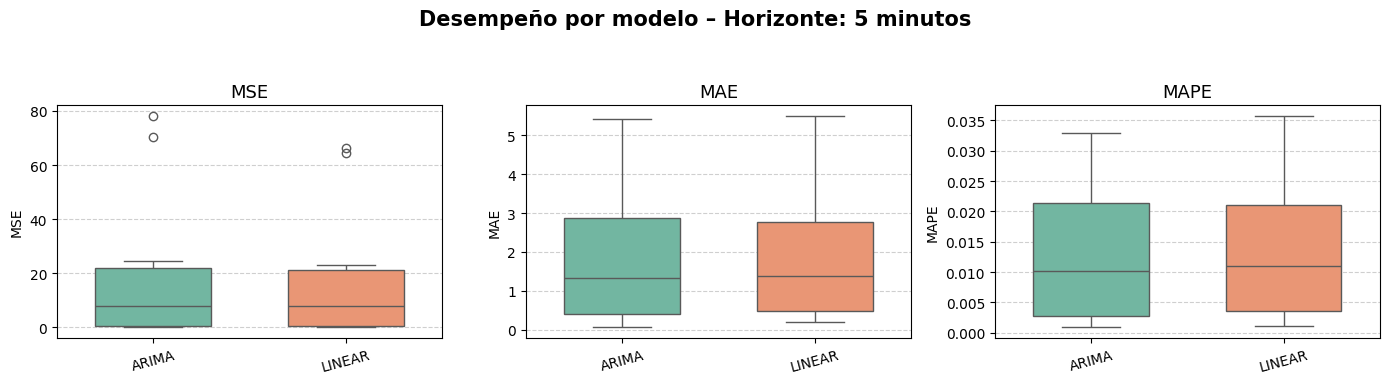

/tmp/ipykernel_387223/2184393272.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_387223/2184393272.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_387223/2184393272.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


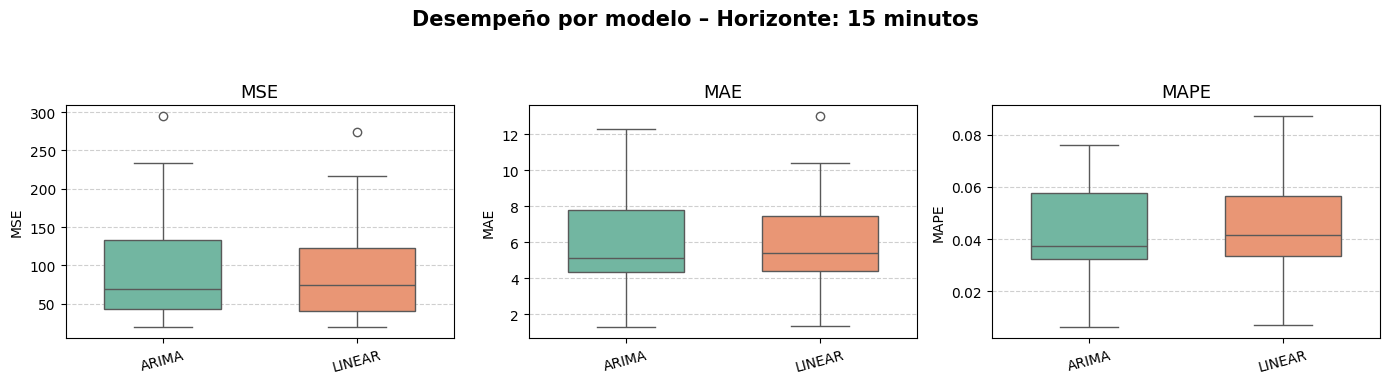

/tmp/ipykernel_387223/2184393272.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_387223/2184393272.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_387223/2184393272.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


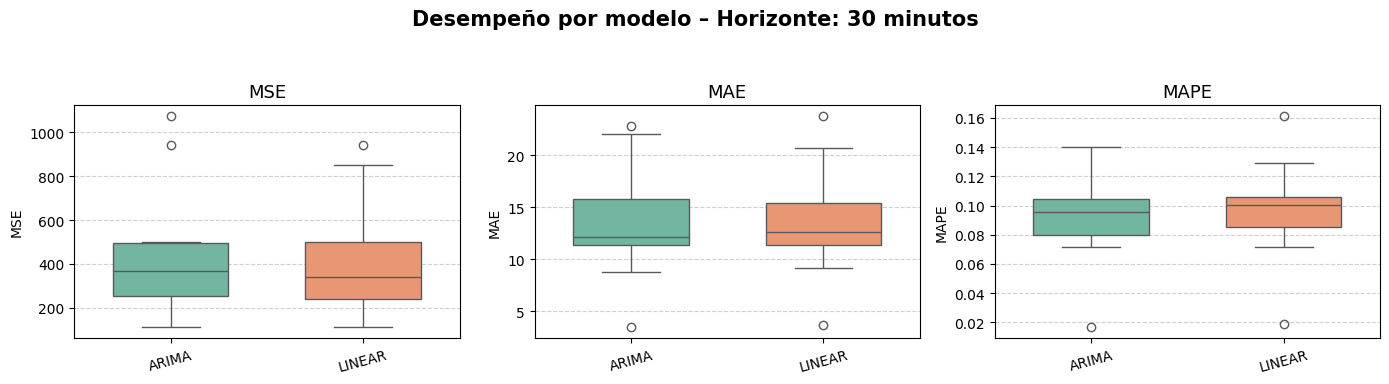

/tmp/ipykernel_387223/2184393272.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_387223/2184393272.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_387223/2184393272.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


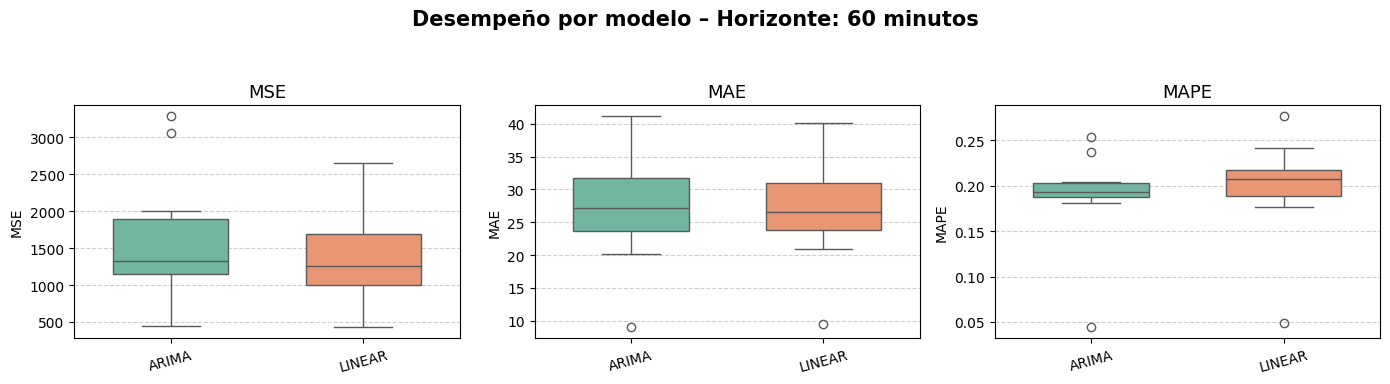

In [84]:
evaluator.visualize_selected_horizons()

In [85]:
evaluator.table_comparasion_metric()

MSE summary:
               1          2           3           4           5           6   \
ARIMA   20.372444  69.689535  106.147807  187.890446  353.978641  455.010907   
LINEAR  18.631110  67.687600  102.020994  179.938237  332.646914  423.528384   

                7           8           9            10           11  \
ARIMA   613.825776  876.148635  970.097187  1204.545283  1487.837238   
LINEAR  562.585209  799.674235  859.697050  1054.538406  1313.320779   

                 12  
ARIMA   1612.190192  
LINEAR  1397.522770  
**************************************************
MAE summary:
              1         2         3         4          5          6   \
ARIMA   1.955954  4.360399  6.096582  8.541731  11.528139  13.547439   
LINEAR  2.027781  4.510169  6.225323  8.619656  11.624395  13.521513   

               7          8          9          10         11         12  
ARIMA   16.085713  19.208075  20.861024  23.341987  25.976306  27.617725  
LINEAR  15.950979  19.159095  20

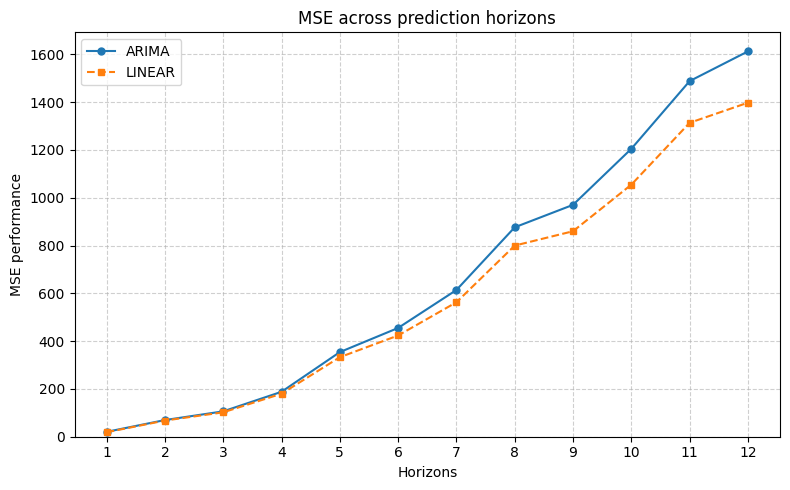

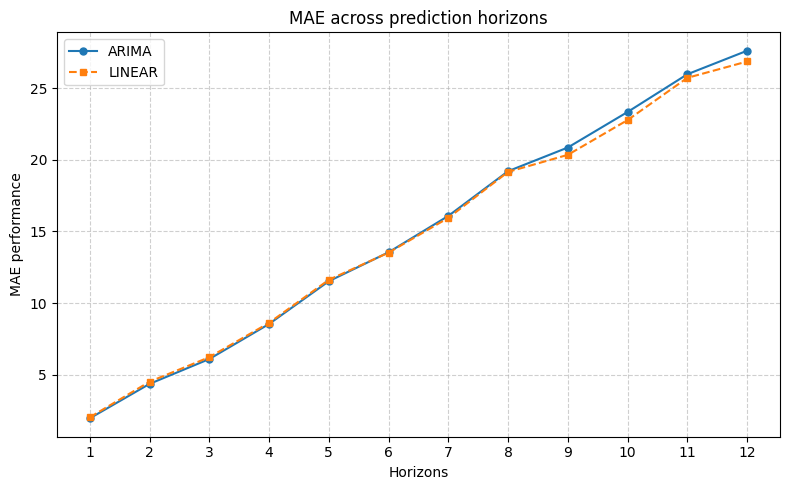

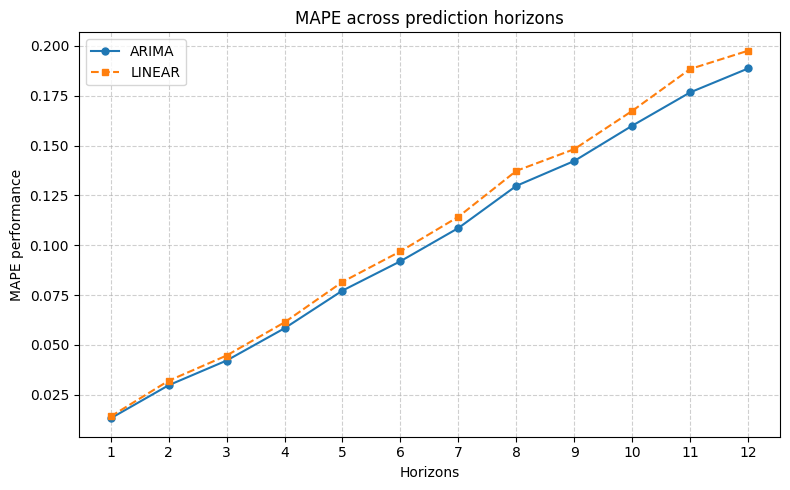

In [86]:
evaluator.plot_horizon_metric_models()